In [54]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
from numba import njit, prange

In [15]:
dir_exp = os.path.expanduser('~/jcope/config/NWPAC025/run/')

# basic.nc explained
The `basic` file in the JCOPE output contains grid data.

Dimensions:
- lon: longitude (range: 0 to 360 deg)
- lat: latitude (range: -90 to 90 deg)
- lev: vertical levels in integers starting from 1
- time: time only has one value which is static.

Variables (time, lev, lat, lon):
- z: the upper depth point (negative values)
- zz: the center depth point (negative values)
- dz: the vertical resolution (positive values; approximately equal to (z - zz)*2)

Text(0.5, 1.0, 'dz - (z-zz)*2 at lev=0')

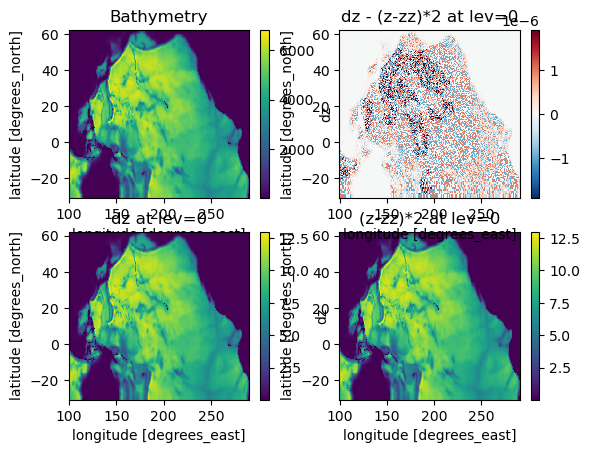

In [14]:
ds = xr.open_dataset(os.path.expanduser('~/jcope/config/NWPAC025/run/basic_01JAN1999.nc'))
plt.subplot(221)
ds["dz"].sum(dim=("lev")).plot()
plt.title('Bathymetry')
plt.subplot(223)
dz = ds["dz"][0,1,:,:]
dz.plot()
plt.title('dz at lev=0')
plt.subplot(224)
z_zz_x2 = ((ds["z"]-ds["zz"])[0,1,:,:]*2)
z_zz_x2.plot()
plt.title('(z-zz)*2 at lev=0')
plt.subplot(222)
(dz - z_zz_x2).plot()
plt.title('dz - (z-zz)*2 at lev=0')

### Interpolation from sigma-coordinate to z-coordinate

In [22]:
z_static

<xarray.DataArray 'zz' (lev: 21, lat: 282, lon: 543)> Size: 13MB
array([[[4.2840610e+00, 4.2840610e+00, 4.3249354e+00, ...,
         2.5000000e-02, 2.5000000e-02, 2.5000000e-02],
        [4.2840610e+00, 4.2840610e+00, 4.3249354e+00, ...,
         2.5000000e-02, 2.5000000e-02, 2.5000000e-02],
        [4.3954167e+00, 4.3954167e+00, 4.4274979e+00, ...,
         1.0322471e+00, 6.8816471e-01, 6.8816471e-01],
        ...,
        [2.5000000e-02, 2.5000000e-02, 2.5000000e-02, ...,
         2.5000000e-02, 2.5000000e-02, 2.5000000e-02],
        [2.5000000e-02, 2.5000000e-02, 2.5000000e-02, ...,
         2.5000000e-02, 2.5000000e-02, 2.5000000e-02],
        [2.5000000e-02, 2.5000000e-02, 2.5000000e-02, ...,
         2.5000000e-02, 2.5000000e-02, 2.5000000e-02]],

       [[1.2852182e+01, 1.2852182e+01, 1.2974806e+01, ...,
         7.5000003e-02, 7.5000003e-02, 7.5000003e-02],
        [1.2852182e+01, 1.2852182e+01, 1.2974806e+01, ...,
         7.5000003e-02, 7.5000003e-02, 7.5000003e-02],
        [1.3186251e+01, 1.3186251e+01, 1.3282494e+01, ...,
         3.0967412e+00, 2.0644941e+00, 2.0644941e+00],
...
         9.7500002e-01, 9.7500002e-01, 9.7500002e-01],
        [9.7500002e-01, 9.7500002e-01, 9.7500002e-01, ...,
         9.7500002e-01, 9.7500002e-01, 9.7500002e-01],
        [9.7500002e-01, 9.7500002e-01, 9.7500002e-01, ...,
         9.7500002e-01, 9.7500002e-01, 9.7500002e-01]],

       [[4.2840605e+03, 4.2840605e+03, 4.3249351e+03, ...,
         1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
        [4.2840605e+03, 4.2840605e+03, 4.3249351e+03, ...,
         1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
        [4.3954165e+03, 4.3954165e+03, 4.4274976e+03, ...,
         1.0322471e+03, 6.8816467e+02, 6.8816467e+02],
        ...,
        [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
         1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
        [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
         1.0000000e+00, 1.0000000e+00, 1.0000000e+00],
        [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
         1.0000000e+00, 1.0000000e+00, 1.0000000e+00]]],
      shape=(21, 282, 543), dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 1999-01-01T12:00:00
  * lon      (lon) float64 4kB 99.88 100.1 100.4 100.6 ... 289.2 289.8 290.2
  * lat      (lat) float64 2kB -30.5 -29.5 -28.5 -27.5 ... 61.62 61.88 62.12
  * lev      (lev) float64 168B 1.0 2.0 3.0 4.0 5.0 ... 17.0 18.0 19.0 20.0 21.0
Attributes:
    long_name:  zz

In [58]:
# 1. Load Data
# basic.dat has time=1
ds_grid = xr.open_dataset(dir_exp+'basic_01JAN1999.nc')
z_static = abs(ds_grid['zz']).squeeze()  # zz values are negatives, so use abs() to convert to positives

# EL has time=3
ds_el = xr.open_dataset(dir_exp+"EL_01JAN1990.nc")
el = ds_el['elm']  # Shape: (3, Lat, Lon)

# Bathymetry (H)
H = ds_grid['dz'].sum("lev").squeeze()

# Load Temperature (Time=3)
ds_t = xr.open_dataset(dir_exp+"T_01JAN1990.nc")
temp = ds_t['tm']  # Shape: (3, Depth, Lat, Lon)

# Define Target Z-Levels (meters)
z_targets = [0, 5, 10, 15, 20, 25, 50, 75, 100, 150, 200, 300, 400, 500]
nt, nz, ny, nx = temp.shape
out_temp = np.full((nt, len(z_targets), ny, nx), np.nan)

# A. Calculate ACTUAL 3D Depth for this specific day
#    Formula: Z_static * (1 + EL / H)
#    We handle the "division by zero" for land points automatically by numpy
sig4d = z_static * (1.0 + el.squeeze()/ H)
sig4d = sig4d.transpose("time","lev","lat","lon")

@njit(parallel=True)
def interpolate_fast(z_daily, temp, z_targets, out_temp):
    nt, nz, ny, nx = temp.shape
    
    # Numba likes explicit loops! 
    # Use 'prange' on the outer loop to use all CPU cores automatically
    for t in prange(nt): 
        for j in range(ny):
            for i in range(nx):
                # Extract columns (Standard numpy slicing works in Numba)
                col_z = z_daily[t, :, j, i]
                col_t = temp[t, :, j, i]
                
                # Numba supports np.interp
                out_temp[t, :, j, i] = np.interp(z_targets, col_z, col_t)

# Run it
interpolate_fast(z_daily.values, temp.values, z_targets, out_temp)


# 3. Save Result
# ... (Save out_temp to NetCDF)

In [61]:
# --- 1. Prepare Data & Coordinates ---
# Assuming 'result_array' is your Numba output with shape (Time, Depth, Lat, Lon)
# Assuming 'z_targets' is your list of new depths [0, 10, 20...]

# Load original files just to grab their coordinates (Lat/Lon/Time)
# (You likely already have these open as ds_t and ds_grid)
time_coords = ds_t['time']   # Use original time
lat_coords  = ds_grid['lat'] # Use original latitude
lon_coords  = ds_grid['lon'] # Use original longitude

# --- 2. Create the DataArray ---
# This attaches dimensions and coordinates to your raw numpy array
da_temp = xr.DataArray(
    data=result_array,
    dims=["time", "depth", "lat", "lon"],  # Explicitly name dimensions
    coords={
        "time": time_coords,
        "depth": z_targets,                # Your NEW fixed Z-levels
        "lat": lat_coords,
        "lon": lon_coords
    },
    name="temp",                           # The variable name inside the file
    attrs={
        "units": "degC",
        "long_name": "Potential Temperature",
        "standard_name": "sea_water_potential_temperature"
    }
)

# --- 3. Pack into a Dataset ---
# A Dataset can hold multiple variables (e.g., add Salt/U/V here later)
ds_out = da_temp.to_dataset()

# Add Global Metadata (Optional but recommended)
ds_out.attrs["title"] = "JCOPE Offline BGC Input (Z-Coordinates)"
ds_out.attrs["description"] = "Interpolated from Sigma to Fixed Z-levels"

# --- 4. Save to NetCDF ---
output_filename = "offline_bgc_input_Z.nc"
ds_out.to_netcdf(output_filename)

print(f"Saved successfully: {output_filename}")
print(ds_out)  # Print summary to verify dimensions

array([[[[20.82219887, 20.73229218, 20.71838951, ...,         nan,
                  nan,         nan],
         [20.74286652, 20.84886932, 20.84633827, ...,         nan,
                  nan,         nan],
         [21.17560959, 21.05827904, 20.99537277, ..., 16.72237778,
          17.09791756, 17.48062706],
         ...,
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [        nan,         nan,         nan, ...,         nan,
                  nan,         nan]],

        [[20.81797619, 20.72116489, 20.70808713, ...,         nan,
                  nan,         nan],
         [20.73175916, 20.84420771, 20.8435517 , ...,         nan,
                  nan,         nan],
         [21.16838066, 21.057257  , 20.99524106, ..., 16.51562725,
          16.97100707, 17.39675552],
         ...,
         [        nan,         nan

### old code keep in case some missing components in the later code below

In [ ]:

# --- CONFIGURATION ---
DT_PHYS = 3600.0   # Physics time step (seconds) [e.g. 1 hour]
DT_BIO  = 86400.0  # Biology time step (seconds) [1 day]
MIX_H   = 100.0    # Horizontal Mixing (m2/s)
FILE_IN = "jcope_zlevel_daily.nc"

def calculate_w_continuity(u, v, dz, dx, dy):
    """
    Re-calculates Vertical Velocity (W) from U, V to ensure mass conservation.
    W_top = W_bot - div(U,V)*dz
    """
    # divergence = du/dx + dv/dy
    # This is a simplified C-grid divergence. 
    # For A-grid (interpolated data), use centered difference.
    
    du_dx = u.differentiate("lon") / dx
    dv_dy = v.differentiate("lat") / dy
    div = du_dx + dv_dy
    
    # Integrate from bottom up (assuming w_bottom = 0)
    w = np.zeros_like(div)
    w_curr = 0.0
    
    # Loop from bottom (k=-1) to top (k=0)
    # Note: JCOPE Z-levels are usually indexed surface->deep.
    # We must integrate deep->surface for stability.
    nz = len(dz)
    for k in range(nz-1, -1, -1):
        # w_top = w_bot - div * dz
        w_curr = w_curr - (div.isel(depth=k).values * dz[k])
        w[:, k, :, :] = w_curr 
        
    return w

def advection_upwind(tracer, u, v, w, dt, dx, dy, dz):
    """
    Simple Upwind Advection Scheme (First Order).
    Stable but diffusive. Good for testing BGC.
    """
    # 1. Fluxes in X
    # If u > 0, take tracer from left (i-1). If u < 0, take from right (i+1).
    # (Implemented using numpy roll for speed)
    c_left = np.roll(tracer, 1, axis=2) 
    c_right = np.roll(tracer, -1, axis=2)
    flux_x = np.where(u > 0, u * c_left, u * c_right)
    
    # 2. Fluxes in Y
    c_down = np.roll(tracer, 1, axis=1)
    c_up   = np.roll(tracer, -1, axis=1)
    flux_y = np.where(v > 0, v * c_down, v * c_up)
    
    # 3. Fluxes in Z
    c_below = np.roll(tracer, 1, axis=0)
    c_above = np.roll(tracer, -1, axis=0)
    flux_z = np.where(w > 0, w * c_below, w * c_above)
    
    # Update Tracer (dC/dt = -div(Flux))
    # Note: This is a pseudo-code implementation. 
    # Real implementation needs strict grid spacing division.
    
    new_tracer = tracer - dt * (
        (flux_x - np.roll(flux_x, -1, axis=2))/dx +
        (flux_y - np.roll(flux_y, -1, axis=1))/dy +
        (flux_z - np.roll(flux_z, -1, axis=0))/dz
    )
    return new_tracer

def vertical_diffusion_implicit(tracer, kv, dt, dz):
    """
    Solves dC/dt = d/dz(Kv dC/dz) using generic tridiagonal solver.
    Essential for mixing nutrients into the surface.
    """
    # Construct Matrix A for A * C_new = C_old
    # This usually requires scipy.sparse.linalg or a custom Thomas Algorithm
    # Placeholder: Just return unmixed for now
    return tracer 

def biology_npzd(nut, phyt, zoo, det, par, temp, dt):
    """
    The Biology Source/Sink Terms (NPZD).
    """
    # Parameters
    alpha = 0.05      # Initial slope P-I curve
    vp    = 0.5       # Max Growth (1/day)
    mo    = 0.05      # Mortality
    graz  = 0.2       # Zooplankton grazing
    
    # 1. Light Limitation (Beer's Law)
    # par_z = par_surface * exp(-k * depth)
    
    # 2. Temp Limitation (Q10)
    # t_func = 1.066 ** temp
    
    # 3. Growth
    # growth = vp * t_func * min(light_lim, nut_lim)
    
    # Update arrays
    # phyt_new = phyt + (growth - grazing - mortality) * dt
    
    return nut, phyt, zoo, det


# --- MAIN LOOP ---

# 1. Load Data
ds = xr.open_dataset(FILE_IN)
u_phys = ds['u'].values  # (Time, Depth, Lat, Lon)
v_phys = ds['v'].values
kz     = ds['kh'].values # Vertical Diffusivity
temp   = ds['temp'].values

# 2. Initialize Tracers (Constant 10.0 for test)
nut  = np.ones_like(u_phys[0]) * 10.0
phyt = np.ones_like(u_phys[0]) * 0.1
zoo  = np.ones_like(u_phys[0]) * 0.1
det  = np.ones_like(u_phys[0]) * 0.1

# 3. Time Stepping
days_to_run = 10
steps = int((days_to_run * 86400) / DT_PHYS)

print(f"Starting Offline Run for {steps} steps...")

for t in range(steps):
    
    # A. Get Physics for this hour
    # (In real code, handle index 't' modulo the file length)
    u_curr = u_phys[t % 24]
    v_curr = v_phys[t % 24]
    k_curr = kz[t % 24]
    
    # B. Calculate W (Mass Conservation)
    # w_curr = calculate_w_continuity(u_curr, v_curr, ...)
    w_curr = np.zeros_like(u_curr) # Placeholder
    
    # C. Advection (Transport)
    nut = advection_upwind(nut, u_curr, v_curr, w_curr, DT_PHYS, 10000, 10000, 10)
    phyt = advection_upwind(phyt, u_curr, v_curr, w_curr, DT_PHYS, 10000, 10000, 10)
    # ... others ...

    # D. Diffusion (Vertical Mixing)
    # nut = vertical_diffusion_implicit(nut, k_curr, DT_PHYS, ...)

    # E. Biology (Only once per day or every step)
    # Convert DT to days!
    dt_days = DT_PHYS / 86400.0
    nut, phyt, zoo, det = biology_npzd(nut, phyt, zoo, det, 0, 0, dt_days)
    
    if t % 24 == 0:
        print(f"Day {t//24}: Surface Nut = {np.mean(nut[0,:,:])}")

# 4. Save Output
ds_out = xr.Dataset(
    {"nut": (("depth", "lat", "lon"), nut)},
    coords=ds.coords
)
ds_out.to_netcdf("offline_bgc_result.nc")

### Offline BGC simulation

In [118]:
# --- 2. PHYSICS FUNCTIONS ---

def calculate_omega_sigma(u, v, layer_thickness, dx, dy):
    nz, ny, nx = u.shape
    omega = np.zeros((nz+1, ny, nx)) 
    
    # 1. Horizontal Divergence (Transport)
    u_trans = u * layer_thickness
    v_trans = v * layer_thickness
    div_h = (np.gradient(u_trans, axis=2)/dx) + (np.gradient(v_trans, axis=1)/dy)
    
    # 2. Integrate Bottom -> Surface
    current_omega = np.zeros((ny, nx))
    for k in range(nz-1, -1, -1):
        current_omega = current_omega - div_h[k,:,:]
        omega[k,:,:]  = current_omega
        
    # 3. LINEAR CORRECTION (The "Leak" Fix)
    # Theoretically, omega[0] (Surface) should be close to 0 (or d(eta)/dt).
    # Due to averaging, it might be non-zero. We subtract this error linearly 
    # from bottom to top to force omega[0] = 0.
    
    surface_error = omega[0,:,:]
    
    # Correction slope per layer
    # We want to subtract 'surface_error' gradually as we go up.
    # At k=nz (bottom), correction is 0. At k=0 (top), correction is surface_error.
    
    for k in range(nz+1):
        # Weight: 0 at bottom, 1 at top
        weight = (nz - k) / nz
        omega[k,:,:] -= surface_error * weight
        
    return omega

def advection_step_advective(tracer, u, v, omega, layer_thickness, dt, dx, dy):
    """
    Split-Operator Advection:
    1. Horizontal (X/Y) - Explicit (Fast)
    2. Vertical (Z) - Adaptive Sub-stepping (Stable)
    """
    nz, ny, nx = tracer.shape
    
    # --- STEP 1: HORIZONTAL ADVECTION (X + Y) ---
    # We assume horizontal CFL is safe with dt=600
    
    # Pad for Neumann BCs (Zero Gradient at edges)
    c_pad_x = np.pad(tracer, ((0,0), (0,0), (1,1)), mode='edge')
    c_pad_y = np.pad(tracer, ((0,0), (1,1), (0,0)), mode='edge')
    
    # Gradients
    dC_dx_minus = (c_pad_x[:, :, 1:-1] - c_pad_x[:, :, :-2]) / dx 
    dC_dx_plus  = (c_pad_x[:, :, 2:]   - c_pad_x[:, :, 1:-1]) / dx 
    adv_x = np.where(u > 0, u * dC_dx_minus, u * dC_dx_plus)
    
    dC_dy_minus = (c_pad_y[:, 1:-1, :] - c_pad_y[:, :-2, :]) / dy
    dC_dy_plus  = (c_pad_y[:, 2:, :]   - c_pad_y[:, 1:-1, :]) / dy
    adv_y = np.where(v > 0, v * dC_dy_minus, v * dC_dy_plus)
    
    # Update Tracer with Horizontal changes ONLY
    tracer_h = tracer - dt * (adv_x + adv_y)
    
    # --- STEP 2: VERTICAL ADVECTION (Z) with SUB-STEPPING ---
    # We must handle the vertical part carefully.
    
    # Sanitize inputs for stability calculation
    w_safe = np.nan_to_num(omega) # Interfaces (nz+1)
    dz_safe = np.maximum(layer_thickness, 0.1) # Avoid zero
    
    # Estimate Max Vertical Velocity in column (approx center)
    w_center = 0.5 * (w_safe[:-1] + w_safe[1:])
    
    # Calculate Max CFL in the entire domain
    # CFL = |w| * dt / dz
    # We use the maximum value to decide how many sub-steps we need
    max_cfl_z = np.max(np.abs(w_center) * dt / dz_safe)
    
    # Determine Sub-steps (Target CFL <= 0.5 for safety)
    n_sub = int(np.ceil(max_cfl_z / 0.5))
    n_sub = max(1, n_sub) # At least 1 step
    n_sub = min(n_sub, 200) # Cap at 200 to prevent freezing
    
    dt_sub = dt / n_sub
    
    tracer_new = tracer_h.copy()
    
    # Perform Vertical Steps
    for sub in range(n_sub):
        
        # Pad Z for gradients
        # Top/Bottom BC: Zero Gradient (Closed)
        c_pad_z = np.pad(tracer_new, ((1,1), (0,0), (0,0)), mode='edge')
        
        dC_dz_minus = (c_pad_z[1:-1] - c_pad_z[:-2]) # C[k] - C[k-1]
        dC_dz_plus  = (c_pad_z[2:]   - c_pad_z[1:-1]) # C[k+1] - C[k]
        
        # We need term: w * dC/dz
        # Since dz varies, we compute dC and divide by dz later, 
        # OR we just treat dC_dz as delta_C and divide by actual thickness.
        
        grad_minus = dC_dz_minus / dz_safe
        grad_plus  = dC_dz_plus  / dz_safe
        
        # Upwind Selection
        # If w > 0 (Upward), flow is from Below (k+1). Use grad_plus?
        # Careful: indices.
        # w > 0 means flow k+1 -> k. We want C[k+1] - C[k]. That is grad_plus.
        
        adv_z = np.where(w_center > 0, w_center * grad_plus, w_center * grad_minus)
        
        tracer_new -= dt_sub * adv_z
        
        # Optional: Clip intermediate negatives
        # tracer_new = np.maximum(tracer_new, 0.0)

    return tracer_new

def vertical_diffusion(tracer, kh, dz, dt):
    """
    Adaptive Explicit Vertical Diffusion.
    Automatically splits 'dt' into smaller steps to ensure stability.
    Stable if Alpha <= 0.5.
    """
    nz, ny, nx = tracer.shape
    
    # 1. Sanitize Inputs
    #    Clamp Kh to be safe (0 to 1.0 m2/s)
    kh = np.clip(np.nan_to_num(kh), 0.0, 1.0)
    
    #    Clamp dz to be safe (min 10cm)
    dz = np.nan_to_num(dz)
    dz_safe = np.maximum(dz, 0.1) 
    
    # 2. Calculate Max Stability Parameter (Alpha)
    #    Alpha = K * dt / dz^2
    #    We need to check the worst case in the whole grid.
    
    #    Use a safe divisor to avoid noise
    min_dz_sq = np.min(dz_safe**2)
    max_kh    = np.max(kh)
    
    max_alpha_raw = (max_kh * dt) / min_dz_sq
    
    # 3. Determine Sub-steps
    #    We need effective_alpha < 0.4 (Safety margin)
    #    dt_sub = dt / N
    #    (K * dt/N) / dz^2 < 0.4  =>  N > (K * dt / dz^2) / 0.4
    
    n_substeps = int(np.ceil(max_alpha_raw / 0.4))
    
    #    Force at least 1 step
    n_substeps = max(1, n_substeps)
    
    #    Limit to reasonable number (if > 100, we probably have bad data)
    if n_substeps > 100:
        # Just clamp it to 100 to prevent freezing, but warn.
        # This acts as a "physics limiter"
        n_substeps = 100
    
    dt_sub = dt / n_substeps
    
    # 4. Run Sub-steps
    tracer_curr = tracer.copy()
    
    #    Pre-calculate geometric factors to save time
    #    Distance between cell centers k and k+1
    dist_interface = 0.5 * (dz_safe[:-1] + dz_safe[1:])
    
    for sub in range(n_substeps):
        
        flux_z = np.zeros((nz+1, ny, nx))
        
        # --- Flux Calculation (Vectorized) ---
        # Interface k connects Layer k-1 (Top) and Layer k (Bottom)
        
        # Kh at interface
        kh_int = 0.5 * (kh[:-1] + kh[1:])
        
        # Gradient C_top - C_bot
        dC = tracer_curr[:-1] - tracer_curr[1:]
        
        # Flux = Kh * dC / dist
        flux_inner = kh_int * dC / dist_interface
        
        # Fill Flux Array (Indices 1 to nz-1)
        flux_z[1:-1] = flux_inner
        
        # Boundaries (0 and nz) remain 0.0 (No Flux)
        
        # --- Update Tracer ---
        # dC/dt = (Flux_in_top - Flux_out_bot) / dz
        
        flux_in  = flux_z[:-1]
        flux_out = flux_z[1:]
        
        divergence = (flux_in - flux_out) / dz_safe
        
        tracer_curr += dt_sub * divergence
        
    return tracer_curr

def biology_npzd(nut, phyt, zoo, det, par, temp, dt):
    """
    The Biology Source/Sink Terms (NPZD).
    """
    # Parameters
    alpha = 0.05      # Initial slope P-I curve
    vp    = 0.5       # Max Growth (1/day)
    mo    = 0.05      # Mortality
    graz  = 0.2       # Zooplankton grazing
    
    # 1. Light Limitation (Beer's Law)
    # par_z = par_surface * exp(-k * depth)
    
    # 2. Temp Limitation (Q10)
    # t_func = 1.066 ** temp
    
    # 3. Growth
    # growth = vp * t_func * min(light_lim, nut_lim)
    
    # Update arrays
    # phyt_new = phyt + (growth - grazing - mortality) * dt
    
    return nut, phyt, zoo, det

def calculate_grid_metrics(ds):
    """
    Calculates 2D arrays for grid spacing dx and dy in meters.
    Assumes standard spherical earth.
    """
    R_EARTH = 6371000.0  # Meters
    
    # 1. Get Lat/Lon (Handle 1D or 2D inputs)
    #    If 1D (rectilinear), we meshgrid them to 2D
    lat = ds['lat'].values
    lon = ds['lon'].values
    
    if lat.ndim == 1:
        # Create 2D grid: (Lat, Lon)
        lon_2d, lat_2d = np.meshgrid(lon, lat)
    else:
        lon_2d, lat_2d = lon, lat
        
    # 2. Convert to Radians
    lat_rad = np.radians(lat_2d)
    lon_rad = np.radians(lon_2d)
    
    # 3. Calculate DY (Distance North-South)
    #    dy = R * d(lat)
    #    We use np.gradient to get the difference at every point
    dlat = np.gradient(lat_rad, axis=0)
    dy = R_EARTH * dlat
    
    # 4. Calculate DX (Distance East-West)
    #    dx = R * cos(lat) * d(lon)
    dlon = np.gradient(lon_rad, axis=1)
    dx = R_EARTH * np.cos(lat_rad) * dlon
    
    # 5. Fix Signs (Gradient direction) & Safety
    #    Distances should always be positive for simple transport division
    dx = np.abs(dx)
    dy = np.abs(dy)
    
    return dx, dy

In [105]:
import numpy as np
import xarray as xr
import glob
import os

# --- 1. CONFIGURATION ---
DT_PHYS = 600.0        # 600 = 10 min (Stable for Advection)
DT_BIO  = 86400.0      # 1 Day (Standard for Biology)
STEPS_PER_DAY = int(DT_BIO / DT_PHYS) # 24 steps

# File Paths (Change these to your actual file names)
DIR_EXP = "~/jcope/config/NWPAC025/run/"
DIR_EXP = os.path.expanduser(DIR_EXP)
LIST_IN_VAR = ["T","S","U","V","KH","EL","NSWR"]
FILE_PATTERN = "*_01JAN1990.nc"  # Must contain U, V, EL
FILE_GRID  = "basic_01JAN1999.nc"               # Must contain dz



# --- 3. MAIN WORKFLOW ---

# A. Load Static Grid (basic.nc)
print("Loading Grid...")
ds_grid = xr.open_dataset(os.path.join(DIR_EXP, FILE_GRID)) # Use os.path.join for safety
dz_static = ds_grid['dz'].values.squeeze()
master_lon = ds_grid['lon']
master_lat = ds_grid['lat']
master_lev = ds_grid['zz']

# CALCULATE BATHYMETRY from sum of dz (Since dz is in meters)
# This sums down the column (axis 0)
H = np.nansum(dz_static, axis=0)
# Mask Land (avoid divide by zero later)
H[H < 0.1] = np.nan

# B. Load Forcing (Daily)
print("Loading Forcing...")
#ds_daily = xr.open_mfdataset(DIR_EXP+FILE_PATTERN)
full_pattern = os.path.join(DIR_EXP, FILE_PATTERN)
files = glob.glob(full_pattern)

# Check if files were found
if not files:
    raise FileNotFoundError(f"No files matched the pattern: {full_pattern}")

print(f"Found {len(files)} files.")

var_patterns = {
    'um':    'U_01JAN1990.nc',
    'vm':    'V_01JAN1990.nc',
    'elm':   'EL_01JAN1990.nc',
    'tm': 'T_01JAN1990.nc',
    'khm':   'KH_01JAN1990.nc'
}

datasets_clean = []

for var_name, pattern in var_patterns.items():
    full_path = os.path.join(DIR_EXP, pattern)
    files = sorted(glob.glob(full_path))
    
    if not files:
        print(f"Warning: No files found for {var_name}")
        continue
        
    print(f"Opening {var_name} ({len(files)} files)...")
    
    # --- THE FIX IS HERE ---
    ds_var = xr.open_mfdataset(
        files, 
        chunks={'time': 1}, 
        parallel=True,
        # Force stacking based on filename order, not internal coordinates
        combine='nested',  
        concat_dim='time'
    )
    
    # Rename internal variable
    old_name = list(ds_var.data_vars)[0]
    ds_var = ds_var.rename({old_name: var_name})
    
    # --- 1. Force Lat/Lon (Always safe) ---
    ds_var = ds_var.assign_coords(lat=master_lat, lon=master_lon)
    
    # --- 2. Handle 'lev' Dimension ---
    if 'lev' in ds_var.dims:
        current_size = ds_var.sizes['lev']
        if current_size == 1:
            ds_var = ds_var.squeeze('lev', drop=True) # Fix EL
        elif current_size == len(master_lev):
            ds_var = ds_var.assign_coords(lev=master_lev) # Fix U, V, T

    datasets_clean.append(ds_var)

# --- Merge ---
print("Merging...")
ds = xr.merge(datasets_clean, join='override', compat='override')
print("Done!")


u_daily  = ds['um'].values   
v_daily  = ds['vm'].values
el_daily = ds['elm'].values 

print("Calculating Grid Metrics (dx, dy)...")
dx_grid, dy_grid = calculate_grid_metrics(ds_grid)


Loading Grid...
Loading Forcing...
Found 14 files.
Opening um (1 files)...
Opening vm (1 files)...
Opening elm (1 files)...
Opening tm (1 files)...
Opening khm (1 files)...
Merging...
Done!
Calculating Grid Metrics (dx, dy)...


In [119]:
# --- C. Initialize Tracer ---
# Use index 0 to get the shape (Lat, Lon)
nut = np.where(np.isnan(u_daily[0]), 0.0, 10.0)
phy = np.where(np.isnan(u_daily[0]), 0.0, 0.1)
zoo  = np.copy(phy)
det  = np.copy(phy)
nt, nz, ny, nx = u_daily.shape

print(f"Starting Offline BGC for {nt} Days...")

# --- TIME LOOP (DAYS) ---
for day in range(1):
#for day in range(nt):
    print(f" Processing Day {day+1} / {nt}")
    
    # 1. Get Daily Forcing & CLEAN IT (NaN -> 0.0)
    #    This prevents NaNs from rolling into the ocean
    u_curr = np.nan_to_num(u_daily[day])
    v_curr = np.nan_to_num(v_daily[day])
    kh_curr = np.nan_to_num(ds['khm'].isel(time=day).values)
    
    # 1. Clean Inputs
    el_curr = np.nan_to_num(el_daily[day])
    
    # 2. Calculate Scale Factor SAFELY
    #    We only divide where H is valid (Water). 
    #    On Land (H <= 0.1 or NaN), we force scale_factor = 1.0 (No stretching).
    
    #    First, ensure H is clean (no NaNs)
    H_clean = np.nan_to_num(H)
    
    #    Create a mask for valid water points
    valid_water = (H_clean > 0.1)
    
    #    Initialize scale factor to 1.0 everywhere
    scale_factor = np.ones_like(H_clean)
    
    #    Only calculate (H + EL) / H where water exists
    #    This prevents "Divide by Zero" and "NaN" entirely.
    scale_factor[valid_water] = (H_clean[valid_water] + el_curr[valid_water]) / H_clean[valid_water]
    
    # 3. Apply to dz
    #    Now scale_factor is guaranteed to be clean (finite numbers).
    dz_dynamic = dz_static * scale_factor[np.newaxis, :, :]
    
    # 4. Final Safety Clamp for dz
    #    Even in water, dz shouldn't be 0. Force min thickness of 1cm.
    dz_dynamic = np.maximum(dz_dynamic, 0.01)
    
    # DEBUG PRINT (Run once to verify)
    if day == 0:
        print(f"Grid Check | Min dz: {np.min(dz_dynamic):.4f} | Max dz: {np.max(dz_dynamic):.4f}")
        if np.any(np.isnan(dz_dynamic)):
            print("CRITICAL: dz_dynamic still contains NaNs!")
    
    # 3. Calculate Omega
    omega = calculate_omega_sigma(u_curr, v_curr, dz_dynamic, dx_grid, dy_grid)
    
    # --- SUB-CYCLE LOOP (PHYSICS) ---
    for step in range(STEPS_PER_DAY):
        
        # 1. Advection (Advective Form - Stable for constant fields)
        nut = advection_step_advective(nut, u_curr, v_curr, omega, dz_dynamic, 
                                       DT_PHYS, dx_grid, dy_grid)
        
        # 2. Vertical Diffusion (Implicit - Stable for thin layers)
        #    Use a safe KH (e.g., 1e-5 or clamped file data)
 #       kh_safe = np.clip(kh_curr, 0.0, 1.0) # Clamp file data
 #       nut = vertical_diffusion(nut, kh_safe, dz_dynamic, DT_PHYS)
        
        # 3. Clipper (Remove negative overshoots)
        nut = np.maximum(nut, 0.0)
        
        # 4. Land Mask (Sanitize "Ghost" values on land)
        #    This prevents garbage from creeping in from the edges
        nut = np.where(dz_dynamic > 0.1, nut, 0.0)
        
    # --- BIOLOGY LOOP (ONCE PER DAY) ---
    # FIX: If running once per day, the dt is 1.0 days (86400s), not DT_PHYS (3600s).
    dt_days = 1.0 
    
    #nut, phy, zoo, det = biology_npzd(nut, phy, zoo, det, 0, 0, dt_days)
    

# 4. Save Output
ds_out = xr.Dataset(
    {"nut": (("depth", "lat", "lon"), nut)},
    coords=ds.coords
)
ds_out.to_netcdf("offline_bgc_result.nc")

print("Run Complete.")

Starting Offline BGC for 3 Days...
 Processing Day 1 / 3
Grid Check | Min dz: 0.0220 | Max dz: 975.0262
Run Complete.


In [120]:
print(ds_out["nut"].min().values,ds_out["nut"].max().values)

0.0 5.34982751893674e+56


In [121]:
ds_grid

<xarray.Dataset> Size: 39MB
Dimensions:  (time: 1, lev: 21, lat: 282, lon: 543)
Coordinates:
  * time     (time) datetime64[ns] 8B 1999-01-01T12:00:00
  * lon      (lon) float64 4kB 99.88 100.1 100.4 100.6 ... 289.2 289.8 290.2
  * lat      (lat) float64 2kB -30.5 -29.5 -28.5 -27.5 ... 61.62 61.88 62.12
  * lev      (lev) float64 168B 1.0 2.0 3.0 4.0 5.0 ... 17.0 18.0 19.0 20.0 21.0
Data variables:
    z        (time, lev, lat, lon) float32 13MB ...
    zz       (time, lev, lat, lon) float32 13MB ...
    dz       (time, lev, lat, lon) float32 13MB 8.568 8.568 8.65 ... 0.05 0.05
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Jan 29 14:20:37 2026: cdo -z zip_1 -f nc4 import_binary...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

# Convert to z-coordinate from sigma-coordinate

In [122]:
import xarray as xr
import numpy as np
import glob
import os

# ================= CONFIGURATION =================
# 1. Define your Fixed Z-Levels (Depths in meters)
#    Focused resolution at surface for biology, coarser at depth.
Z_LEVELS = np.array([
    0, 2, 5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 
    250, 300, 400, 500, 600, 800, 1000, 1500, 2000, 3000, 4000, 5000
])

# 2. Paths 
INPUT_DIR = "~/jcope/config/NWPAC025/run/"          # Where your files are (e.g., U_01JAN1990.nc)
INPUT_DIR = os.path.expanduser(DIR_EXP)
OUTPUT_DIR = INPUT_DIR+'Z_COORD/' # Where new files will go
GRID_FILE = 'basic_01JAN1999.nc'  # Pattern to find the grid file

# Ensure output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================= HELPER FUNCTIONS =================

def calculate_grid_metrics(ds):
    """Calculates dx, dy in meters from lat/lon."""
    R_EARTH = 6371000.0
    lat = ds['lat'].values
    lon = ds['lon'].values
    
    # Handle 1D lat/lon
    if lat.ndim == 1:
        lon_2d, lat_2d = np.meshgrid(lon, lat)
    else:
        lon_2d, lat_2d = lon, lat
        
    lat_rad = np.radians(lat_2d)
    lon_rad = np.radians(lon_2d)
    
    dlat = np.gradient(lat_rad, axis=0)
    dlon = np.gradient(lon_rad, axis=1)
    
    dy = R_EARTH * dlat
    dx = R_EARTH * np.cos(lat_rad) * dlon
    
    return np.abs(dx), np.abs(dy)

def interp_column(src_data, src_z, tgt_z):
    """
    Interpolates a single 1D column (Z-axis).
    Used by apply_ufunc for vectorization.
    """
    # np.interp requires x-coordinates to be increasing. 
    # JCOPE z usually increases with index (0=surface, 20=bottom).
    # If src_z is all NaN (Land), return NaNs.
    if np.all(np.isnan(src_z)):
        return np.full_like(tgt_z, np.nan)
        
    # Interpolate
    # left=NaN, right=NaN ensures we don't extrapolate below sea floor
    return np.interp(tgt_z, src_z, src_data, left=np.nan, right=np.nan)

def recompute_w(u, v, dz_levels, dx, dy):
    """
    Integrates Continuity Equation on Z-Grid to get W.
    div_h + dw/dz = 0  =>  dw = -div_h * dz
    """
    nz, ny, nx = u.shape
    w = np.zeros((nz+1, ny, nx)) # Defined at interfaces
    
    # Calculate Horizontal Divergence
    # Fill NaNs with 0.0 for continuity integration
    u_safe = np.nan_to_num(u)
    v_safe = np.nan_to_num(v)
    
    # Gradient (Central Difference)
    # Note: np.gradient handles boundaries, but simple difference is robust
    du_dx = np.gradient(u_safe, axis=2) / dx
    dv_dy = np.gradient(v_safe, axis=1) / dy
    div_h = du_dx + dv_dy
    
    # Integrate from Bottom up (Assuming flat bottom at max depth implies w=0)
    # Or Surface down (Rigid Lid, w=0 at z=0). Surface down is usually safer for Z-levels.
    
    # W_top = 0.0
    # W_k+1 = W_k - (div_h_k * dz_k)
    
    current_w = np.zeros((ny, nx)) # Start at surface (0)
    
    # Calculate dz for each cell (distance between levels)
    # We approximated levels as box centers or interfaces. 
    # Let's assume Z_LEVELS are the centers for simplicity, or interfaces.
    # Standard: Z_LEVELS are cell centers. We need dz of the cell.
    # Approximation: dz[k] = z[k+1] - z[k] (roughly).
    
    # Let's stick to the Z-Levels provided as "Depth of the slice"
    # Create simple thickness array
    dz_layers = np.diff(Z_LEVELS)
    dz_layers = np.append(dz_layers, dz_layers[-1]) # Pad last
    
    # Integrate Surface Down
    for k in range(nz):
        # Flow out of bottom of layer k
        # w_next = w_curr + (dw/dz * dz) = w_curr - (div_h * dz)
        w[k+1] = w[k] - div_h[k] * dz_layers[k]
        
    # Masking: Where inputs were Land (0.0), W should remain 0.0
    # Use U-mask to clean up W
    mask_land = (u_safe[0] == 0)
    w[:, mask_land] = 0.0
    
    # Return W at cell centers (average of interfaces) to match T/S grid
    w_centered = 0.5 * (w[:-1] + w[1:])
    return w_centered

# ================= MAIN LOOP =================

def process_day(date_str):
    print(f"Converting Date: {date_str}...")
    
    # 1. Load Files
    # Finds U_01JAN1990.nc, etc.
    try:
        ds_u = xr.open_dataset(os.path.join(INPUT_DIR, f"U_{date_str}.nc"))
        ds_v = xr.open_dataset(os.path.join(INPUT_DIR, f"V_{date_str}.nc"))
        ds_t = xr.open_dataset(os.path.join(INPUT_DIR, f"T_{date_str}.nc"))
        ds_s = xr.open_dataset(os.path.join(INPUT_DIR, f"S_{date_str}.nc"))
        ds_kh = xr.open_dataset(os.path.join(INPUT_DIR, f"KH_{date_str}.nc"))
        ds_el = xr.open_dataset(os.path.join(INPUT_DIR, f"EL_{date_str}.nc"))
        
        # Load Basic Grid (Contains 'z' or 'dz')
        # Note: Basic file might have a different date or be static. 
        # Using the one from the list: 'basic_01JAN1999.nc' or matching date.
        # Let's try to find a matching basic file, or fallback to the generic one.
        basic_files = sorted(glob.glob(os.path.join(INPUT_DIR, f"basic_01JAN1999.nc")))
        ds_basic = xr.open_dataset(basic_files[0]) # Use the first one found
        
    except FileNotFoundError as e:
        print(f"  Skipping {date_str}: File missing ({e})")
        return

    # 2. Get 3D Depth Grid from Basic File
    # Variable 'z' in basic file usually is (lev, lat, lon) or (lev,)
    # We need the 3D depth of every sigma cell to interpolate.
    if 'z' in ds_basic:
        sigma_depth_3d = ds_basic['z'] # Shape (21, 282, 543)
    else:
        # If 'z' is missing, construct it from 'dz'
        # Depth = Integral(dz)
        dz = ds_basic['dz']
        sigma_depth_3d = dz.cumsum(dim='lev') - (dz * 0.5) # Center of layer
        
    # 3. Setup Interpolation
    # We use xarray.apply_ufunc to vectorize the column interpolation
    # This loops over Lat/Lon efficiently in C/Numpy
    
    vars_to_interp = {
        'um': ds_u['um'], 
        'vm': ds_v['vm'], 
        'tm': ds_t['tm'],
        'sm': ds_s['sm'], 
        'khm': ds_kh['khm']
    }
    
    interp_results = {}
    
    for var_name, da in vars_to_interp.items():
        print(f"  Interpolating {var_name}...")
        
        # Handle time dimension if present (squeeze it out for processing)
        if 'time' in da.dims:
            da = da.isel(time=0)
        
        # Core Interpolation
        # Input: (lev), Output: (z_new)
        # Vectorize over lat, lon
        out = xr.apply_ufunc(
            interp_column,
            da,                # Source Data
            sigma_depth_3d,    # Source Z (3D)
            Z_LEVELS,          # Target Z (1D)
            input_core_dims=[['lev'], ['lev'], ['z_new']],
            output_core_dims=[['z_new']],
            vectorize=True,    # Loop over other dims (lat, lon)
            dask='forbidden',
            output_dtypes=[np.float32],
            kwargs={}
        )
        
        # Transpose back to (z, lat, lon)
        out = out.transpose('z_new', 'lat', 'lon')
        interp_results[var_name] = out

    # 4. Recompute Omega (W)
    print("  Recomputing Omega (W)...")
    dx, dy = calculate_grid_metrics(ds_u)
    
    w_new = recompute_w(
        interp_results['u'].values, 
        interp_results['v'].values, 
        Z_LEVELS, dx, dy
    )
    
    # 5. Create Final Dataset
    ds_out = xr.Dataset(
        data_vars={
            'um': (('depth', 'lat', 'lon'), interp_results['um'].values),
            'vm': (('depth', 'lat', 'lon'), interp_results['vm'].values),
            'wm': (('depth', 'lat', 'lon'), w_new),
            'tm': (('depth', 'lat', 'lon'), interp_results['tm'].values),
            'sm': (('depth', 'lat', 'lon'), interp_results['sm'].values),
            'khm': (('depth', 'lat', 'lon'), interp_results['khm'].values),
            'elm': (('lat', 'lon'), ds_el['elm'].isel(time=0).values), # Surface Height
            'nswrm': (('lat', 'lon'), xr.open_dataset(os.path.join(INPUT_DIR, f"NSWR_{date_str}.nc"))['nswrm'].isel(time=0).values)
        },
        coords={
            'depth': Z_LEVELS,
            'lat': ds_u.lat,
            'lon': ds_u.lon,
            'time': ds_u.time # Keep original time
        }
    )
    
    # Save
    out_name = os.path.join(OUTPUT_DIR, f"JCOPE_Z_{date_str}.nc")
    ds_out.to_netcdf(out_name)
    print(f"  Saved: {out_name}")

# ================= RUNNER =================
# Find all U files to get dates
u_files = sorted(glob.glob(os.path.join(INPUT_DIR, "U_*.nc")))
for f in u_files:
    # Extract date part: U_01JAN1990.nc -> 01JAN1990
    base = os.path.basename(f)
    date_part = base.replace("U_", "").replace(".nc", "")
    
    process_day(date_part)

print("Conversion Complete.")

Converting Date: 01JAN1990...


KeyError: "No variable named 'khm'. Did you mean one of ('kh',)?"

In [124]:
date_part

'01JAN1990'